### This notebook compute "VCA10. Progress in Preparation of the Water Resources Management Plan for the basin" indicator for the 27 basins of IKI Project

Spanish: Avance en la elaboración del Plan de Gestión de Recursos Hídricos de la cuenca

**Created:** 11/10/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:** 1/12/2026 by Sophia Bakar (sbakar@rti.org)

**Status:** Complete and loaded in SQLite for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad

**Packages:** pandas, numpy, geopandas, sqlite3, matplotlib, unicodedata  
 
**Inputs:**   Shapefile of COMIDs and districts, Excel with status from ANA (Fronseca)

**Outputs:** Indicator score (0, 0.5, 1) for the CRHC's progress in the plan
 
**Assumptions:** Subbasins with no data are assigned NaN. 

**N/A Handling:** COMIDs with no data in the management plan data frame are assigned a value of 0, which is the same value for COMIDs with "no tiene" data entry.   
 
**Future work:** 
 
**Notes:** 

General Methodology:  
1. Standardize basin names in management plan data frame (pfrh_df). Merge with subbasins shapefile.  
2. Assign scores to estado del plan: 1 for "aprobado" (approved), 0.5 for "cuenta con algún avance" (in preparation), and 0 for "no tiene" (no plan). Basins with no data are also assigned zero.  

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
import unicodedata
import matplotlib.patches as mpatches

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 510 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#PGRH = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Datos\Planes_Gestion\Estado de PGRH.xlsx'
PGRH = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Datos\Planes_Gestion\Estado de PGRH.xlsx"

In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
pgrh_df = pd.read_excel(PGRH)

C:\Users\sbakar\AppData\Roaming\Python\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [6]:
#format the prgh dataframe
#make second row the header
pgrh_df.columns = pgrh_df.iloc[1]
pgrh_df = pgrh_df[2:]

In [7]:
# Function to remove accents from strings
def remove_accents(text):
    if pd.isna(text):
        return text
    # Normalize to NFD (decomposed form) and filter out combining characters
    return ''.join(c for c in unicodedata.normalize('NFD', str(text)) 
                   if unicodedata.category(c) != 'Mn')


In [8]:
# Map PGRH status to subbasins
# For each COMID in subbasin_gdf, add the estado del plan column based on matching cuencas, ignoring any differences in accents
# Create normalized versions of the Cuenca column in both dataframes
# Remove "Cuenca" prefix from subbasins_gdf before normalizing
subbasins_gdf['Cuenca_normalized'] = (
    subbasins_gdf['Cuenca']
    .str.replace('Cuenca', '', case=False, regex=False)  # Remove "Cuenca" prefix
    .apply(remove_accents)
    .str.strip()
    .str.upper()
)

pgrh_df['Cuenca_normalized'] = (
    pgrh_df['Cuenca']
    .apply(remove_accents)
    .str.strip()
    .str.upper()
)

# Merge based on the normalized Cuenca column
subbasins_with_pgrh = subbasins_gdf.merge(
    pgrh_df[['Cuenca_normalized', 'Estado del Plan']], 
    on='Cuenca_normalized', 
    how='left'
)

# Drop the temporary normalized column
subbasins_with_pgrh = subbasins_with_pgrh.drop(columns=['Cuenca_normalized'])

# Display results
print(f"Total COMIDs: {len(subbasins_with_pgrh)}")
print(f"COMIDs with PGRH status: {subbasins_with_pgrh['Estado del Plan'].notna().sum()}")
print(f"\nPGRH Status Distribution:")
print(subbasins_with_pgrh['Estado del Plan'].value_counts())

Total COMIDs: 3655
COMIDs with PGRH status: 3533

PGRH Status Distribution:
Estado del Plan
Aprobado                   2255
No tiene                    908
Cuenta con algún avance     370
Name: count, dtype: int64


In [9]:
# Assign scores based on "Estado del Plan"

def assign_pgrh_score(estado):
    if pd.isna(estado):
        return np.nan  # No plan
    estado_lower = str(estado).lower().strip()
    
    if 'aprobado' in estado_lower:
        return 1  # Plan approved/implemented
    elif 'cuenta con algún avance' in estado_lower or 'elaboracion' in estado_lower:
        return 0.5  # Plan in preparation
    elif 'no tiene' in estado_lower or 'sin' in estado_lower:
        return 0  # No plan
    else:
        return 0  # Assume if there is no data, no plan

# Apply scoring function
subbasins_with_pgrh['PGRH_Score'] = subbasins_with_pgrh['Estado del Plan'].apply(assign_pgrh_score)

# Display score distribution
print("\nPGRH Score Distribution:")
print(subbasins_with_pgrh['PGRH_Score'].value_counts().sort_index())
print(f"\nCOMIDs without PGRH data: {subbasins_with_pgrh['PGRH_Score'].isna().sum()}")


PGRH Score Distribution:
PGRH_Score
0.0     908
0.5     370
1.0    2255
Name: count, dtype: int64

COMIDs without PGRH data: 122


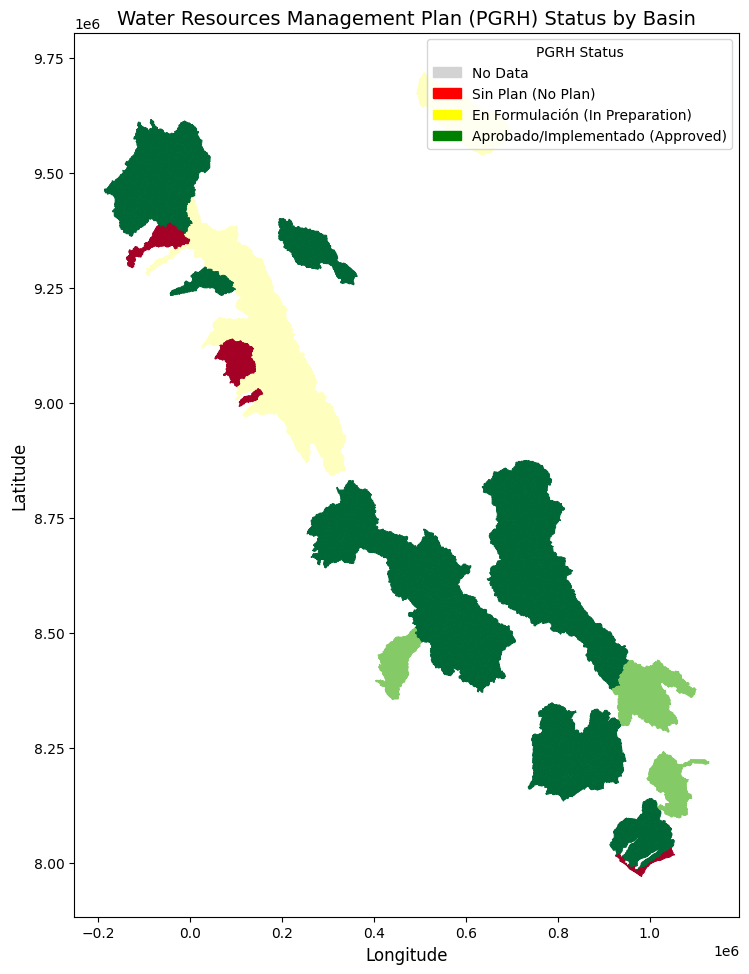

In [10]:
# Plot PGRH scores in a map

fig, ax = plt.subplots(figsize=(12, 10))

# Create a temporary column for plotting that handles NaN
subbasins_with_pgrh['PGRH_Score_plot'] = subbasins_with_pgrh['PGRH_Score'].fillna(-1)

# Plot with custom colors
subbasins_with_pgrh.plot(column='PGRH_Score_plot', ax=ax, legend=False, 
                          cmap='RdYlGn', edgecolor='face', linewidth=0.5)

# Create custom legend
legend_labels = {
    -1: 'No Data',
    0: 'Sin Plan (No Plan)',
    0.5: 'En Formulación (In Preparation)',
    1: 'Aprobado/Implementado (Approved)'
}
colors = {-1: 'lightgrey', 0: 'red', 0.5: 'yellow', 1: 'green'}

# Create patches for the legend
patches = [mpatches.Patch(color=colors[key], label=legend_labels[key]) 
           for key in sorted(legend_labels.keys())]

# Add legend
ax.legend(handles=patches, loc='upper right', title='PGRH Status')

plt.title('Water Resources Management Plan (PGRH) Status by Basin', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.show()

SQLITE INSERT 

In [11]:
# insert results into the database 
insert_data= subbasins_with_pgrh
value_column= 'PGRH_Score' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [12]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_with_pgrh['PGRH_Score']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 510  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index  PGRH_Score
0    min         0.0
1    max         1.0
2  count      3533.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [13]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()